In [1]:
import json
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import MinMaxScaler

# Path to Bob's folder
bob_folder = "C:/Users/edadd/Desktop/bitirme/data"

# List all JSON files in the folder
json_files = [f for f in os.listdir(bob_folder) if f.endswith(".json")]

# Initialize an empty list to store all packets
all_packets = []

# Loop through each JSON file
for file in json_files:
    with open(os.path.join(bob_folder, file), "r") as f:
        data = json.load(f)
        all_packets.extend(data["packets"])  # Append packet list

# Convert JSON data to a Pandas DataFrame
df = pd.DataFrame(all_packets)

# Select relevant columns
df = df[["hour", "minute", "second", "size", "source_port", "destination_port", "ttl", "protocol", "tcp_flags"]]

# **Dynamically One-Hot Encode Protocols**
df = pd.get_dummies(df, columns=["protocol"], prefix="protocol")

# Convert TCP flags (SYN, ACK, FIN) to numeric values
df["tcp_flags"] = df["tcp_flags"].astype(str)
df["SYN"] = df["tcp_flags"].apply(lambda x: int("SYN=true" in x))
df["ACK"] = df["tcp_flags"].apply(lambda x: int("ACK=true" in x))
df["FIN"] = df["tcp_flags"].apply(lambda x: int("FIN=true" in x))

# Drop unnecessary columns
df.drop(columns=["tcp_flags"], inplace=True)

#filled ttl column with median value
df['ttl'].fillna((df['ttl'].median()), inplace=True)

# Normalize data
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

# Check if NaN values still exist
if np.isnan(df_scaled).any():
    print("Warning: NaN values exist after scaling!")

    
print("Scaled Data Shape:", df_scaled.shape)
print("Scaled Data Sample:")
print(df_scaled[:5])


# Convert to LSTM input format (Create sequences)
def create_sequences(data, sequence_length=50):
    sequences = []
    for i in range(len(data) - sequence_length):
        sequences.append(data[i : i + sequence_length])
    return np.array(sequences)

sequence_length = 50  # Use 50 packets per sequence
lstm_input = create_sequences(df_scaled, sequence_length)

# Print final shape
print("LSTM Input Shape:", lstm_input.shape)  # (num_sequences, sequence_length, num_features)


Scaled Data Shape: (33064, 12)
Scaled Data Sample:
[[0.         0.         0.28813559 0.00706941 0.9030076  0.00603687
  0.00378458 1.         0.         0.         1.         0.        ]
 [0.         0.         0.28813559 0.01413882 0.00603687 0.9030076
  0.24996566 1.         0.         0.         1.         0.        ]
 [0.         0.         0.27118644 0.00771208 0.90875037 0.43559897
  1.         0.         1.         1.         0.         0.        ]
 [0.         0.         0.27118644 0.         0.43559897 0.90875037
  0.00379984 1.         0.         0.         1.         0.        ]
 [0.         0.         0.28813559 0.00771208 0.90878133 0.90876585
  1.         0.         1.         1.         0.         0.        ]]
LSTM Input Shape: (33014, 50, 12)


C:\Users\edadd\AppData\Local\Temp\ipykernel_2980\4039666792.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ttl'].fillna((df['ttl'].median()), inplace=True)


In [2]:
# Convert the scaled data back to a DataFrame
df_scaled_df = pd.DataFrame(df_scaled, columns=df.columns)

# Save the DataFrame to a CSV file
df_scaled_df.to_csv("C:/Users/edadd/Desktop/bitirme/csv/bob_data.csv", index=False)

**CNN + LSTM hybrid with Bidirectional LSTM**

In [3]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Bidirectional, Dropout, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import Input

# Define the input shape
timesteps = sequence_length  # Adjust based on your data
n_features = lstm_input.shape[2]  # Adjust based on your scaled data features

# Input layer
input_layer = Input(shape=(timesteps, n_features))

# CNN for feature extraction
conv = Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(input_layer)
conv = MaxPooling1D(pool_size=2, padding="same")(conv)

# Encoder with Bidirectional LSTM
encoded = Bidirectional(LSTM(64, activation="relu", return_sequences=True))(conv)
encoded = Bidirectional(LSTM(32, activation="relu", return_sequences=False))(encoded)  # Latent space

# Decoder with LSTM layers
decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(32, activation="relu", return_sequences=True)(decoded)
decoded = LSTM(64, activation="relu", return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(n_features))(decoded)

# Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 50, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 25, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 50, 12)         │           780 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,660 (576.80 KB)

 Trainable params: 147,660 (576.80 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
X_train = lstm_input.reshape((lstm_input.shape[0] ,  lstm_input.shape[1], lstm_input.shape[2]))
print(X_train.shape)

(33014, 50, 12)


In [5]:
# Train the model
history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=64, validation_split=0.2, shuffle=True)


Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 27s 48ms/step - loss: 0.1003 - val_loss: 0.0338
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - loss: 0.0380 - val_loss: 0.0315
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - loss: 0.0345 - val_loss: 0.0287
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - loss: 0.0315 - val_loss: 0.0269
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - loss: 0.0303 - val_loss: 0.0262
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - loss: 0.0294 - val_loss: 0.0263
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 0.0285 - val_loss: 0.0256
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - loss: 0.0283 - val_loss: 0.0248
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - loss: 0.0278 - val_loss: 0.0250
Epoch 10/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - loss: 0.0274 - val_loss: 0.0247
Epoch 11/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - loss: 0.0271 - val_loss: 0.0243
Epoch 12/50
413/413 ━━━━━━━━━━

In [6]:
#model save
autoencoder.save("C:/Users/edadd/Desktop/bitirme/model/CNN_LSTM_Bidirectional_model.h5")

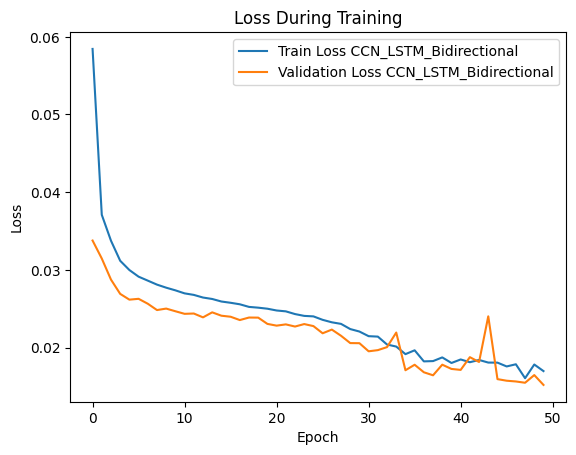

In [7]:
import matplotlib.pyplot as plt

# Plot the loss for training and validation sets
plt.plot(history.history['loss'], label='Train Loss CCN_LSTM_Bidirectional')
plt.plot(history.history['val_loss'], label='Validation Loss CCN_LSTM_Bidirectional')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.show()


**LSTM AUTOENCODER MODEL**

In [9]:
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed
from tensorflow.keras.models import Sequential

# Define the LSTM Autoencoder model
lstm_autoencoder = Sequential([
    LSTM(64, activation="relu", input_shape=(timesteps, n_features), return_sequences=True),
    LSTM(32, activation="relu", return_sequences=False),  # Latent space
    RepeatVector(timesteps),  # Expand back to original sequence length
    LSTM(32, activation="relu", return_sequences=True),
    LSTM(64, activation="relu", return_sequences=True),
    TimeDistributed(Dense(n_features))  # Output layer
])

# Compile the model
lstm_autoencoder.compile(optimizer="adam", loss="mse")
lstm_autoencoder.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 50, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 50, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 50, 12)         │           780 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,060 (258.05 KB)

 Trainable params: 66,060 (258.05 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_lstm = lstm_autoencoder.fit(X_train, X_train, epochs=50, batch_size=64, validation_split=0.2, shuffle=True)


Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - loss: 0.0892 - val_loss: 0.0351
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - loss: 0.0398 - val_loss: 0.0327
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 0.0358 - val_loss: 0.0290
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 0.0321 - val_loss: 0.0275
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 0.0306 - val_loss: 0.0267
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 0.0301 - val_loss: 0.0260
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 0.0293 - val_loss: 0.0256
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 0.0287 - val_loss: 0.0254
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 0.0286 - val_loss: 0.0250
Epoch 10/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 0.0279 - val_loss: 0.0251
Epoch 11/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - loss: 0.0279 - val_loss: 0.0244
Epoch 12/50
413/413 ━━━━━━━━━━

In [11]:
lstm_autoencoder.save("C:/Users/edadd/Desktop/bitirme/model/just_lstm_autoencoder.h5")


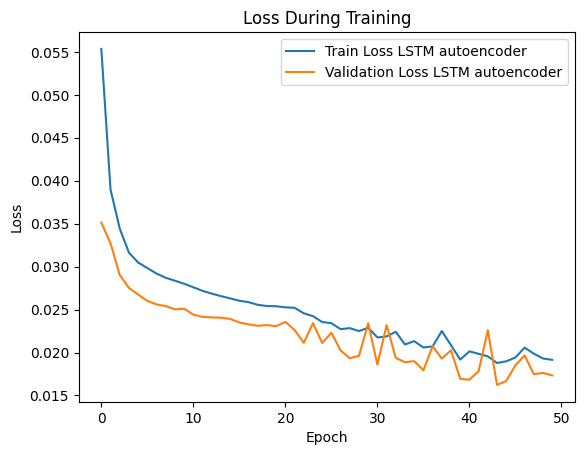

In [12]:
import matplotlib.pyplot as plt

# Plot the loss for training and validation sets
plt.plot(history_lstm.history['loss'], label='Train Loss LSTM autoencoder')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss LSTM autoencoder' )
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.show()

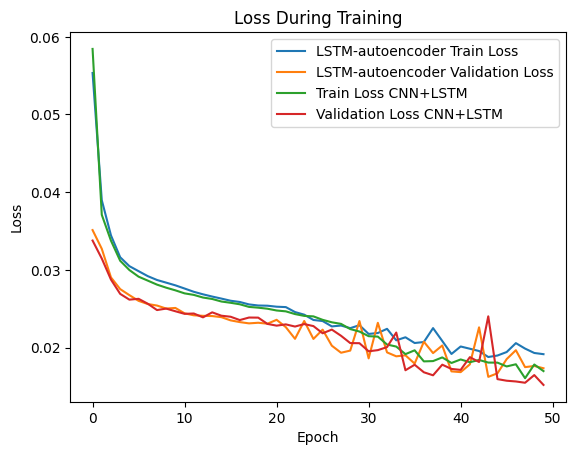

In [13]:
import matplotlib.pyplot as plt

# Plot the loss for training and validation sets
plt.plot(history_lstm.history['loss'], label='LSTM-autoencoder Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM-autoencoder Validation Loss')
plt.plot(history.history['loss'], label='Train Loss CNN+LSTM')
plt.plot(history.history['val_loss'], label='Validation Loss CNN+LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.show()

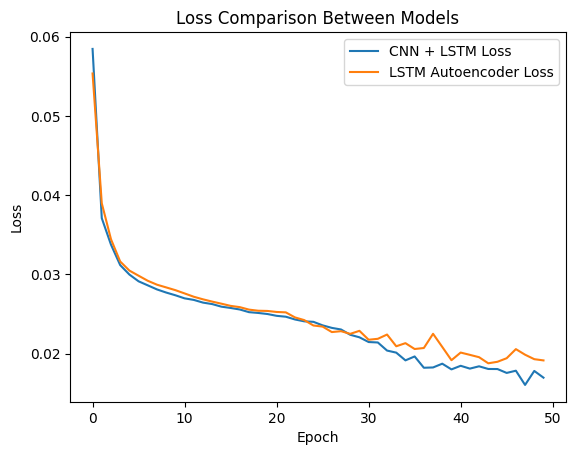

In [14]:
plt.plot(history.history['loss'], label='CNN + LSTM Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Autoencoder Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison Between Models')
plt.legend()
plt.show()


In [15]:
import pickle

# Scaler'ı kaydet
with open("C:/Users/edadd/Desktop/bitirme/scaler/scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)

Ağ Anormalliği Tespit Modeli Karşılaştırması
------------------------------------------
Anormal veri bulunamadı. Test için sentetik anormal veri oluşturulacak.
Sentetik anormal veri oluşturuluyor...
Sentetik anormal veri oluşturuldu ve kaydedildi.
Normal test dizileri: (6563, 50, 12)
Anormal test dizileri: (6563, 50, 12)
411/411 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step
CNN+LSTM Değerlendirme:
Ortalama MSE: 20.661275
Medyan MSE: 14.928971
Min MSE: 0.422576
Max MSE: 2219.122933
411/411 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step
LSTM Değerlendirme:
Ortalama MSE: 7.882688
Medyan MSE: 7.509010
Min MSE: 0.199531
Max MSE: 18.187944
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
CNN+LSTM (Normal) Değerlendirme:
Ortalama MSE: 37.785273
Medyan MSE: 20.478724
Min MSE: 14.383405
Max MSE: 2219.122933
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
CNN+LSTM (Anormal) Değerlendirme:
Ortalama MSE: 3.543486
Medyan MSE: 0.907120
Min MSE: 0.422576
Max MSE: 183.671987
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
LSTM (Normal) Değerlendi

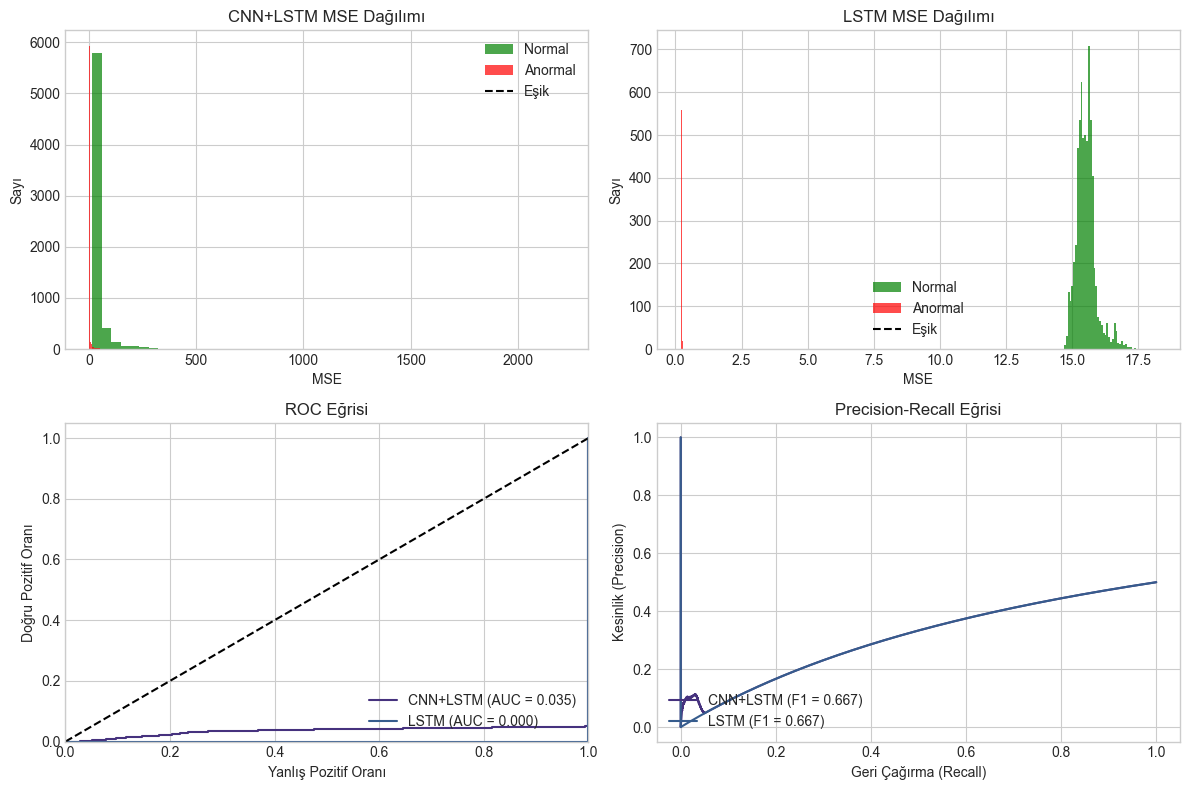

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


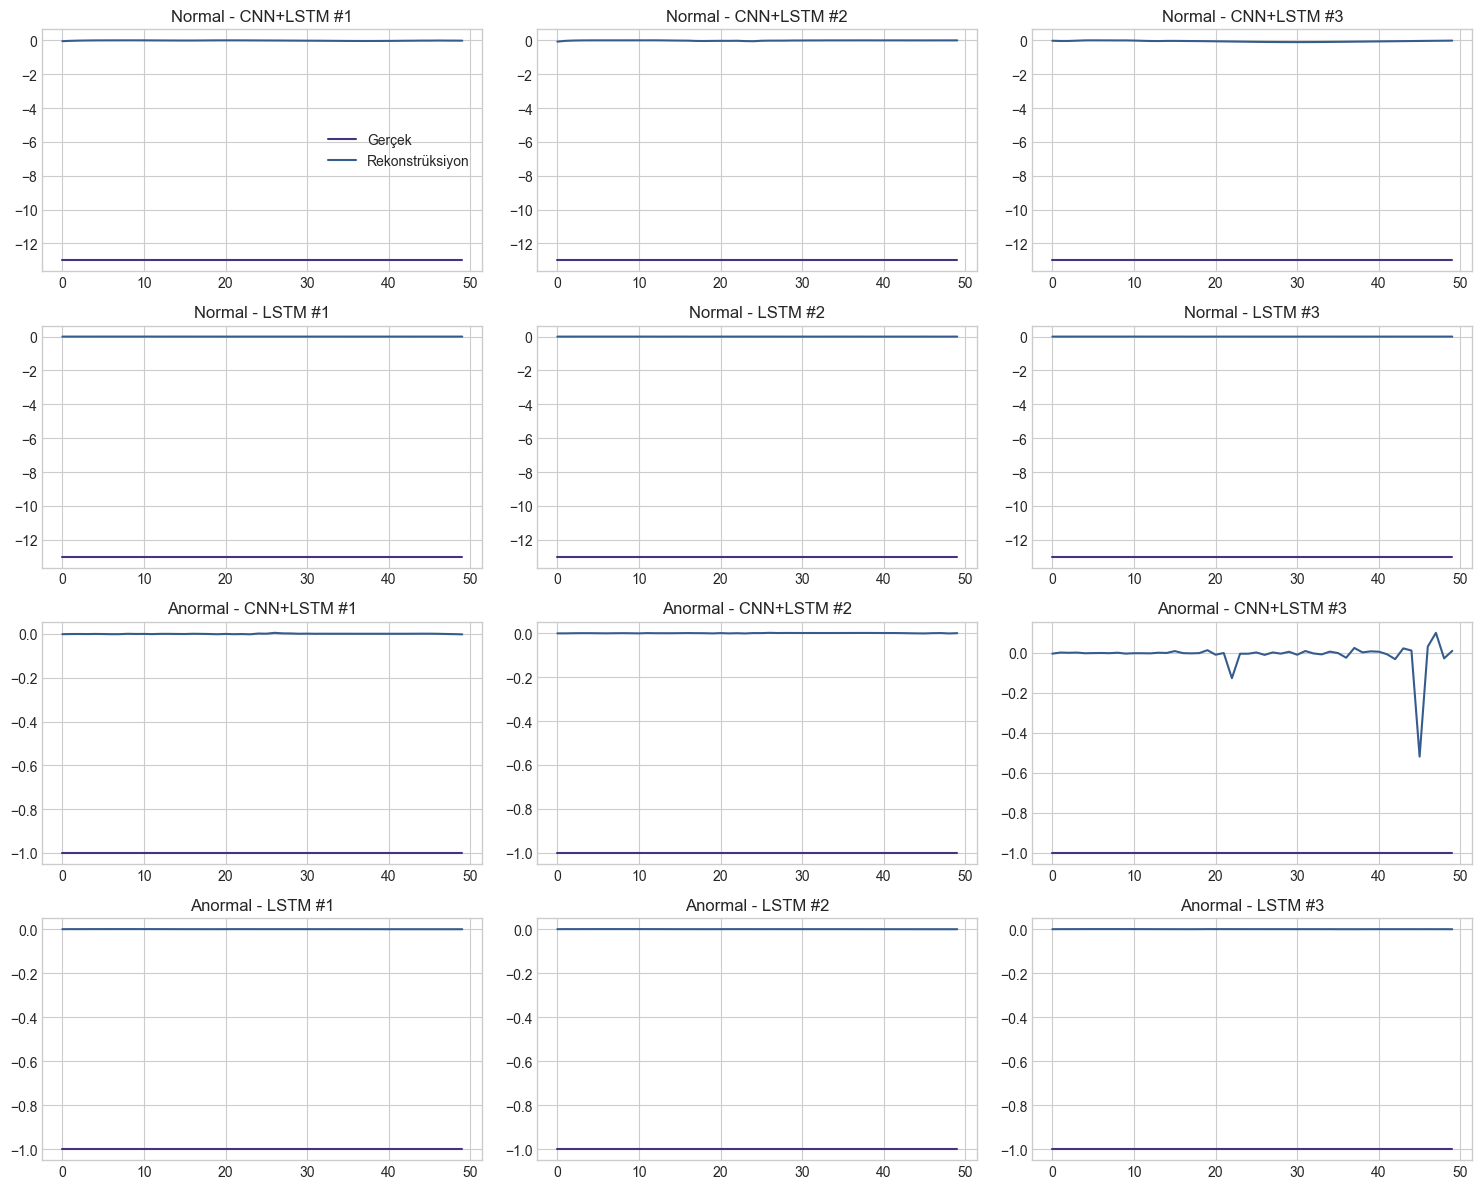


Karşılaştırma sonuçları:
CNN+LSTM AUC: 0.0353, F1: 0.6667
LSTM AUC: 0.0000, F1: 0.6667

CNN+LSTM modeli, AUC metriğine göre daha iyi performans gösteriyor.
LSTM modeli, F1 skoruna göre daha iyi performans gösteriyor.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_curve, roc_curve, auc, f1_score
import pickle
import json
import os
import seaborn as sns
from tensorflow.keras.losses import mse



# Görsel stili ayarla
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# ---------- 1. Modelleri ve Gerekli Verileri Yükle ----------
def load_models_and_data():
    """Eğitilmiş modelleri ve test verilerini yükler"""
    # Modelleri yükle
    cnn_lstm_model = load_model("C:/Users/edadd/Desktop/bitirme/model/CNN_LSTM_Bidirectional_model.h5", 
                           custom_objects={'mse': mse})
    lstm_model = load_model("C:/Users/edadd/Desktop/bitirme/model/just_lstm_autoencoder.h5",
                       custom_objects={'mse': mse})
    
    # Scaler'ı yükle (eğer kaydedilmişse)
    try:
        with open("C:/Users/edadd/Desktop/bitirme/scaler/scaler.pkl", 'rb') as f:
            scaler = pickle.load(f)
    except FileNotFoundError:
        print("Scaler dosyası bulunamadı. Lütfen önce scaler'ı kaydedin.")
        return None, None, None, None
    
    # Test verisi yükleme ve hazırlama (normal ve anormal veriler)
    # Normal verileri yükle
    normal_data = pd.read_csv("C:/Users/edadd/Desktop/bitirme/csv/bob_data.csv")
    
    # Eğer anormal veri varsa yükle, yoksa oluştur
    try:
        abnormal_data = pd.read_csv("C:/Users/edadd/Desktop/bitirme/abnormal_data.csv")
        print(f"Anormal veri yüklendi: {len(abnormal_data)} satır")
    except FileNotFoundError:
        print("Anormal veri bulunamadı. Test için sentetik anormal veri oluşturulacak.")
        abnormal_data = None
    
    return cnn_lstm_model, lstm_model, scaler, normal_data, abnormal_data

# ---------- 2. Test Verisi Oluşturma ----------
def create_test_data(normal_data, abnormal_data, scaler, sequence_length=50, test_ratio=0.2):
    """Normal ve anormal verilerden test veri setini oluşturur"""
    
    # Normal verinin bir kısmını test için ayır
    n_test = int(len(normal_data) * test_ratio)
    test_normal_data = normal_data.iloc[-n_test:].copy()
    
    # Eğer anormal veri yoksa, sentetik anormal veri oluştur
    if abnormal_data is None:
        print("Sentetik anormal veri oluşturuluyor...")
        # Normal veriden anormal veri oluştur - farklı saatler ve büyük paketler
        abnormal_data = test_normal_data.copy()
        
        # 1. Saat değerlerini değiştir (gece saatleri)
        abnormal_data['hour'] = (abnormal_data['hour'] + 12) % 24
        
        # 2. Paket boyutlarını artır
        abnormal_data['size'] = abnormal_data['size'] * np.random.uniform(5, 10, len(abnormal_data))
        
        # 3. Port numaralarını değiştir (nadir kullanılan portlar)
        abnormal_data['source_port'] = np.random.randint(50000, 65000, len(abnormal_data))
        abnormal_data['destination_port'] = np.random.choice([22, 3389, 4444, 8080], len(abnormal_data))
        
        # Sentetik anormal veriyi kaydet
        abnormal_data.to_csv("C:/Users/edadd/Desktop/bitirme/synthetic_abnormal_data.csv", index=False)
        print("Sentetik anormal veri oluşturuldu ve kaydedildi.")
    
    # Veriyi ölçeklendir
    test_normal_scaled = scaler.transform(test_normal_data)
    abnormal_scaled = scaler.transform(abnormal_data)
    
    # Dizileri oluştur
    def create_sequences(data, seq_length):
        sequences = []
        for i in range(len(data) - seq_length + 1):
            sequences.append(data[i:i + seq_length])
        return np.array(sequences)
    
    # Normal ve anormal diziler
    normal_sequences = create_sequences(test_normal_scaled, sequence_length)
    abnormal_sequences = create_sequences(abnormal_scaled, sequence_length)
    
    print(f"Normal test dizileri: {normal_sequences.shape}")
    print(f"Anormal test dizileri: {abnormal_sequences.shape}")
    
    # Etiketleri oluştur (0: normal, 1: anormal)
    normal_labels = np.zeros(len(normal_sequences))
    abnormal_labels = np.ones(len(abnormal_sequences))
    
    # Veri setlerini ve etiketleri birleştir
    X_test = np.vstack([normal_sequences, abnormal_sequences])
    y_test = np.concatenate([normal_labels, abnormal_labels])
    
    return X_test, y_test, normal_sequences, abnormal_sequences

# ---------- 3. Modelleri Değerlendir ----------
def evaluate_model(model, test_data, name="Model"):
    """Modelin test verisi üzerindeki rekonstrüksiyon hatalarını hesaplar"""
    
    # Rekonstrüksiyon tahminleri
    reconstructions = model.predict(test_data)
    
    # MSE hesapla
    mse = np.mean(np.power(test_data - reconstructions, 2), axis=(1, 2))
    
    print(f"{name} Değerlendirme:")
    print(f"Ortalama MSE: {np.mean(mse):.6f}")
    print(f"Medyan MSE: {np.median(mse):.6f}")
    print(f"Min MSE: {np.min(mse):.6f}")
    print(f"Max MSE: {np.max(mse):.6f}")
    
    return mse

# ---------- 4. Modelleri Karşılaştır ----------
def compare_models(cnn_lstm_model, lstm_model, X_test, y_test, normal_sequences, abnormal_sequences):
    """İki modelin performansını karşılaştırır ve görselleştirmeler oluşturur"""
    
    # Her iki model için MSE hesapla
    cnn_lstm_mse = evaluate_model(cnn_lstm_model, X_test, "CNN+LSTM")
    lstm_mse = evaluate_model(lstm_model, X_test, "LSTM")
    
    # Normal ve anormal veri için ayrı ayrı MSE hesapla
    cnn_lstm_normal_mse = evaluate_model(cnn_lstm_model, normal_sequences, "CNN+LSTM (Normal)")
    cnn_lstm_abnormal_mse = evaluate_model(cnn_lstm_model, abnormal_sequences, "CNN+LSTM (Anormal)")
    
    lstm_normal_mse = evaluate_model(lstm_model, normal_sequences, "LSTM (Normal)")
    lstm_abnormal_mse = evaluate_model(lstm_model, abnormal_sequences, "LSTM (Anormal)")
    
    # ---------- 5. Eşik Değeri ve Performans Metrikleri ----------
    # ROC eğrisi ve AUC hesaplama
    def calculate_metrics(mse, labels):
        fpr, tpr, thresholds = roc_curve(labels, mse)
        roc_auc = auc(fpr, tpr)
        
        # En iyi eşik değerini bul (Youden indeksi)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]
        
        # Precision-Recall eğrisi
        precision, recall, pr_thresholds = precision_recall_curve(labels, mse)
        
        # F1 skoru için eşik değeri bul
        f1_scores = []
        for threshold in pr_thresholds:
            y_pred = (mse >= threshold).astype(int)
            f1 = f1_score(labels, y_pred)
            f1_scores.append(f1)
        
        best_f1_idx = np.argmax(f1_scores)
        best_f1_threshold = pr_thresholds[best_f1_idx]
        best_f1 = f1_scores[best_f1_idx]
        
        return {
            'fpr': fpr,
            'tpr': tpr,
            'roc_auc': roc_auc,
            'optimal_threshold': optimal_threshold,
            'precision': precision,
            'recall': recall,
            'best_f1_threshold': best_f1_threshold,
            'best_f1': best_f1
        }
    
    # Metrikler hesaplanıyor
    cnn_lstm_metrics = calculate_metrics(cnn_lstm_mse, y_test)
    lstm_metrics = calculate_metrics(lstm_mse, y_test)
    
    # Eşik değerlerini yazdır
    print("\nEşik Değerleri:")
    print(f"CNN+LSTM ROC eşiği: {cnn_lstm_metrics['optimal_threshold']:.6f}")
    print(f"CNN+LSTM F1 eşiği: {cnn_lstm_metrics['best_f1_threshold']:.6f}")
    print(f"LSTM ROC eşiği: {lstm_metrics['optimal_threshold']:.6f}")
    print(f"LSTM F1 eşiği: {lstm_metrics['best_f1_threshold']:.6f}")
    
    # ---------- 6. Görselleştirmeler ----------
    # MSE dağılımlarını görselleştir
    plt.figure(figsize=(12, 8))
    
    plt.subplot(2, 2, 1)
    plt.hist(cnn_lstm_normal_mse, bins=50, alpha=0.7, label='Normal', color='green')
    plt.hist(cnn_lstm_abnormal_mse, bins=50, alpha=0.7, label='Anormal', color='red')
    plt.axvline(cnn_lstm_metrics['optimal_threshold'], color='black', linestyle='dashed', label='Eşik')
    plt.title('CNN+LSTM MSE Dağılımı')
    plt.xlabel('MSE')
    plt.ylabel('Sayı')
    plt.legend()
    
    plt.subplot(2, 2, 2)
    plt.hist(lstm_normal_mse, bins=50, alpha=0.7, label='Normal', color='green')
    plt.hist(lstm_abnormal_mse, bins=50, alpha=0.7, label='Anormal', color='red')
    plt.axvline(lstm_metrics['optimal_threshold'], color='black', linestyle='dashed', label='Eşik')
    plt.title('LSTM MSE Dağılımı')
    plt.xlabel('MSE')
    plt.ylabel('Sayı')
    plt.legend()
    
    # ROC eğrilerini çiz
    plt.subplot(2, 2, 3)
    plt.plot(cnn_lstm_metrics['fpr'], cnn_lstm_metrics['tpr'], label=f'CNN+LSTM (AUC = {cnn_lstm_metrics["roc_auc"]:.3f})')
    plt.plot(lstm_metrics['fpr'], lstm_metrics['tpr'], label=f'LSTM (AUC = {lstm_metrics["roc_auc"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Yanlış Pozitif Oranı')
    plt.ylabel('Doğru Pozitif Oranı')
    plt.title('ROC Eğrisi')
    plt.legend(loc="lower right")
    
    # Precision-Recall eğrilerini çiz
    plt.subplot(2, 2, 4)
    plt.plot(cnn_lstm_metrics['recall'], cnn_lstm_metrics['precision'], 
             label=f'CNN+LSTM (F1 = {cnn_lstm_metrics["best_f1"]:.3f})')
    plt.plot(lstm_metrics['recall'], lstm_metrics['precision'], 
             label=f'LSTM (F1 = {lstm_metrics["best_f1"]:.3f})')
    plt.xlabel('Geri Çağırma (Recall)')
    plt.ylabel('Kesinlik (Precision)')
    plt.title('Precision-Recall Eğrisi')
    plt.legend(loc="lower left")
    
    plt.tight_layout()
    plt.savefig("C:/Users/edadd/Desktop/bitirme/model_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # ---------- 7. Rekonstrüksiyon Örnekleri ----------
    # Rastgele birkaç normal ve anormal örnek seç
    n_samples = 3
    normal_indices = np.random.choice(len(normal_sequences), n_samples, replace=False)
    abnormal_indices = np.random.choice(len(abnormal_sequences), n_samples, replace=False)
    
    # Seçilen örnekleri rekonstrükte et
    normal_samples = normal_sequences[normal_indices]
    abnormal_samples = abnormal_sequences[abnormal_indices]
    
    cnn_lstm_normal_recon = cnn_lstm_model.predict(normal_samples)
    cnn_lstm_abnormal_recon = cnn_lstm_model.predict(abnormal_samples)
    
    lstm_normal_recon = lstm_model.predict(normal_samples)
    lstm_abnormal_recon = lstm_model.predict(abnormal_samples)
    
    # Rekonstrüksiyon karşılaştırma grafiği
    plt.figure(figsize=(15, 12))
    
    for i in range(n_samples):
        # Normal örnek - CNN+LSTM
        plt.subplot(4, n_samples, i + 1)
        plt.plot(normal_samples[i, :, 0], label='Gerçek')
        plt.plot(cnn_lstm_normal_recon[i, :, 0], label='Rekonstrüksiyon')
        plt.title(f'Normal - CNN+LSTM #{i+1}')
        if i == 0:
            plt.legend()
        
        # Normal örnek - LSTM
        plt.subplot(4, n_samples, i + 1 + n_samples)
        plt.plot(normal_samples[i, :, 0], label='Gerçek')
        plt.plot(lstm_normal_recon[i, :, 0], label='Rekonstrüksiyon')
        plt.title(f'Normal - LSTM #{i+1}')
        
        # Anormal örnek - CNN+LSTM
        plt.subplot(4, n_samples, i + 1 + 2*n_samples)
        plt.plot(abnormal_samples[i, :, 0], label='Gerçek')
        plt.plot(cnn_lstm_abnormal_recon[i, :, 0], label='Rekonstrüksiyon')
        plt.title(f'Anormal - CNN+LSTM #{i+1}')
        
        # Anormal örnek - LSTM
        plt.subplot(4, n_samples, i + 1 + 3*n_samples)
        plt.plot(abnormal_samples[i, :, 0], label='Gerçek')
        plt.plot(lstm_abnormal_recon[i, :, 0], label='Rekonstrüksiyon')
        plt.title(f'Anormal - LSTM #{i+1}')
    
    plt.tight_layout()
    plt.savefig("C:/Users/edadd/Desktop/bitirme/reconstruction_examples.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # ---------- 8. Sonuçları Kaydet ----------
    results = {
        "cnn_lstm": {
            "mean_mse": float(np.mean(cnn_lstm_mse)),
            "roc_auc": float(cnn_lstm_metrics["roc_auc"]),
            "best_f1": float(cnn_lstm_metrics["best_f1"]),
            "optimal_threshold": float(cnn_lstm_metrics["optimal_threshold"])
        },
        "lstm": {
            "mean_mse": float(np.mean(lstm_mse)),
            "roc_auc": float(lstm_metrics["roc_auc"]),
            "best_f1": float(lstm_metrics["best_f1"]),
            "optimal_threshold": float(lstm_metrics["optimal_threshold"])
        }
    }
    
    with open("C:/Users/edadd/Desktop/bitirme/model_comparison_results.json", 'w') as f:
        json.dump(results, f, indent=4)
    
    print("\nKarşılaştırma sonuçları:")
    print(f"CNN+LSTM AUC: {cnn_lstm_metrics['roc_auc']:.4f}, F1: {cnn_lstm_metrics['best_f1']:.4f}")
    print(f"LSTM AUC: {lstm_metrics['roc_auc']:.4f}, F1: {lstm_metrics['best_f1']:.4f}")
    
    # Hangi model daha iyi performans gösteriyor?
    if cnn_lstm_metrics['roc_auc'] > lstm_metrics['roc_auc']:
        print("\nCNN+LSTM modeli, AUC metriğine göre daha iyi performans gösteriyor.")
    else:
        print("\nLSTM modeli, AUC metriğine göre daha iyi performans gösteriyor.")
    
    if cnn_lstm_metrics['best_f1'] > lstm_metrics['best_f1']:
        print("CNN+LSTM modeli, F1 skoruna göre daha iyi performans gösteriyor.")
    else:
        print("LSTM modeli, F1 skoruna göre daha iyi performans gösteriyor.")

# ---------- Ana Program ----------
if __name__ == "__main__":
    print("Ağ Anormalliği Tespit Modeli Karşılaştırması")
    print("------------------------------------------")
    
    # Modelleri ve verileri yükle
    cnn_lstm_model, lstm_model, scaler, normal_data, abnormal_data = load_models_and_data()
    
    if cnn_lstm_model is None:
        print("Modeller veya veriler yüklenemedi. Program sonlandırılıyor.")
        exit()
    
    # Test verisini hazırla
    X_test, y_test, normal_sequences, abnormal_sequences = create_test_data(
        normal_data, abnormal_data, scaler, sequence_length=50
    )
    
    # Modelleri karşılaştır
    compare_models(cnn_lstm_model, lstm_model, X_test, y_test, normal_sequences, abnormal_sequences)